**Importing the Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

**Download NLTK resources**

In [2]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MTB\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MTB\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MTB\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\MTB\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

**Loading the dataset**

In [3]:
df = pd.read_csv("../dataset/amazon_alexa.tsv", sep="\t")
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


### Data Exploration Section

**Displaying first 5 rows**

In [4]:
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


**Displaying Last 5 rows**

In [5]:
df.tail()

,rating,date,variation,verified_reviews,feedback
3145,5,30-Jul-18,Black Dot,"Perfect for kids, adults and everyone in betwe...",1
3146,5,30-Jul-18,Black Dot,"Listening to music, searching locations, check...",1
3147,5,30-Jul-18,Black Dot,"I do love these things, i have them running my...",1
3148,5,30-Jul-18,White Dot,Only complaint I have is that the sound qualit...,1
3149,4,29-Jul-18,Black Dot,Good,1


**Dataset Shape**

In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (3150, 5)


**Displaying Column Names**

In [7]:
print(df.columns)

Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='object')


**Displaying Dataset Information**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


Displaying Statistical Summary of the Dataset

In [9]:
df.describe()

,rating,feedback
count,3150.000000,3150.000000
mean,4.463175,0.918413
std,1.068506,0.273778
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


Displaying Statistical Summary Including Text Columns

In [10]:
df.describe(include='all')

,rating,date,variation,verified_reviews,feedback
count,3150.000000,3150,3150,3149,3150.000000
unique,NaN,77,16,2300,NaN
top,NaN,30-Jul-18,Black Dot,,NaN
freq,NaN,1603,516,79,NaN
mean,4.463175,NaN,NaN,NaN,0.918413
std,1.068506,NaN,NaN,NaN,0.273778
min,1.000000,NaN,NaN,NaN,0.000000
25%,4.000000,NaN,NaN,NaN,1.000000
50%,5.000000,NaN,NaN,NaN,1.000000
75%,5.000000,NaN,NaN,NaN,1.000000


Displaying Missing Values

In [11]:
print(df.isnull().sum())

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


Displaying Duplicate Records

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 715


Displaying Unique Values

In [13]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].nunique())


rating
5

date
77

variation
16

verified_reviews
2300

feedback
2


Displaying Random Reviews

In [14]:
df.sample(5)

,rating,date,variation,verified_reviews,feedback
257,5,29-Jul-18,Charcoal Fabric,Very pleased with the Echo 2nd Generation. It ...,1
2680,5,30-Jul-18,White Dot,Easy set up,1
106,5,30-Jul-18,Charcoal Fabric,Very easy to set up. Works wonderful and I lov...,1
747,5,30-Jul-18,Charcoal Fabric,Works as you’d expect and then some. Also good...,1
1911,4,26-Jul-18,Black Plus,Still needs some work on commands. Sound is eq...,1


### Observations

- The dataset contains approximately 3,150 reviews.
- There are 5 columns.
- The target variable is `feedback`.
- Most columns contain no missing values.
- Duplicate reviews may be present and will be handled during preprocessing.
- The review text is stored in the `verified_reviews` column.

### Data Cleaning Section

**Checking Missing Values**

In [16]:
df.isnull().sum()
df = df.dropna(subset=["verified_reviews"])

**Checking Duplicate Rows**

In [17]:
print("Duplicate rows before cleaning:", df.duplicated().sum())

Duplicate rows before cleaning: 715


**Remove Duplicate Rows**

In [18]:
df = df.drop_duplicates()

**Verify Duplicates Were Removed**

In [19]:
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


**Keeping only Requried Columns**

In [20]:
df = df[["verified_reviews", "feedback"]]

**Rename Columns**

In [21]:
df = df.rename(columns={
    "verified_reviews": "review",
    "feedback": "sentiment"
})

**Display the Updated Dataset**

In [22]:
df.head()

,review,sentiment
0,Love my Echo!,1
1,Loved it!,1
2,"Sometimes while playing a game, you can answer...",1
3,I have had a lot of fun with this thing. My 4 ...,1
4,Music,1


**Checking the Shape of the Dataset again**

In [23]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2434, 2)


**Verify Data Types**

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2434 entries, 0 to 2800
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     2434 non-null   object
 1   sentiment  2434 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 57.0+ KB


### Observations

- Missing values were checked and handled.
- Duplicate records were removed.
- Only the review text and sentiment label were retained.
- The dataset is now ready for text preprocessing.

## Basic Text Preprocessing

**Importing Required Libraries**

In [25]:
import re
import string

**Create a Cleaning Function**

In [26]:
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

**Applying the Function**

In [27]:
df["clean_review"] = df["review"].apply(clean_text)

**Comparing Before and After**

In [28]:
df[["review", "clean_review"]].head(10)

,review,clean_review
0,Love my Echo!,love my echo
1,Loved it!,loved it
2,"Sometimes while playing a game, you can answer...",sometimes while playing a game you can answer ...
3,I have had a lot of fun with this thing. My 4 ...,i have had a lot of fun with this thing my yr ...
4,Music,music
5,I received the echo as a gift. I needed anothe...,i received the echo as a gift i needed another...
6,"Without having a cellphone, I cannot use many ...",without having a cellphone i cannot use many o...
7,I think this is the 5th one I've purchased. I'...,i think this is the th one ive purchased im wo...
8,looks great,looks great
9,Love it! I’ve listened to songs I haven’t hear...,love it i’ve listened to songs i haven’t heard...


**Check for Missing Values**

In [29]:
df["clean_review"].isnull().sum()

np.int64(0)

**Displaying Random Examples**

In [30]:
df[["review", "clean_review"]].sample(5, random_state=42)

,review,clean_review
438,Love,love
2481,Love my echo. Love playing music in my room,love my echo love playing music in my room
612,Worked as advertised. Thanks,worked as advertised thanks
1452,I'm loving my new Echo Show. The video screen ...,im loving my new echo show the video screen ad...
2471,I AM COMPLETELY IN LOVE. DOES ABSOLUTELY EVERY...,i am completely in love does absolutely everyt...


### Observations

- All reviews were converted to lowercase.
- Punctuation marks were removed.
- Numerical values were removed.
- Extra spaces were eliminated.
- A new column (`clean_review`) was created while preserving the original review text.

### Tokenization and Stopword Removal

**Importing Required Libraries**

In [31]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

**Loading English Stopwords**

In [32]:
stop_words = set(stopwords.words('english'))

**Creating the Function**

In [33]:
def remove_stopwords(text):
    words = word_tokenize(text)

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

**Applying the Function**

In [34]:
df["processed_review"] = df["clean_review"].apply(remove_stopwords)

**Comparing the Results**

In [35]:
df[["review",
    "clean_review",
    "processed_review"]].head(10)

,review,clean_review,processed_review
0,Love my Echo!,love my echo,love echo
1,Loved it!,loved it,loved
2,"Sometimes while playing a game, you can answer...",sometimes while playing a game you can answer ...,sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,i have had a lot of fun with this thing my yr ...,lot fun thing yr old learns dinosaurs control ...
4,Music,music,music
5,I received the echo as a gift. I needed anothe...,i received the echo as a gift i needed another...,received echo gift needed another bluetooth so...
6,"Without having a cellphone, I cannot use many ...",without having a cellphone i cannot use many o...,without cellphone use many features ipad see u...
7,I think this is the 5th one I've purchased. I'...,i think this is the th one ive purchased im wo...,think th one ive purchased im working getting ...
8,looks great,looks great,looks great
9,Love it! I’ve listened to songs I haven’t hear...,love it i’ve listened to songs i haven’t heard...,love ’ listened songs ’ heard since childhood ...


**Viewing Random Examples**

In [36]:
df[["review",
    "processed_review"]].sample(10, random_state=42)

,review,processed_review
438,Love,love
2481,Love my echo. Love playing music in my room,love echo love playing music room
612,Worked as advertised. Thanks,worked advertised thanks
1452,I'm loving my new Echo Show. The video screen ...,im loving new echo show video screen adds much...
2471,I AM COMPLETELY IN LOVE. DOES ABSOLUTELY EVERY...,completely love absolutely everything amazing ...
2328,I don't like how I cannot load my Hulu account...,dont like load hulu account also slow know int...
1814,I decided to buy smart door lock and decided o...,decided buy smart door lock decided getting ec...
1417,I LOVE THIS ITEM... I UNDERESTIMATED THIS ITEM...,love item underestimated item another cart im ...
251,Simply love my Echo. I hardly watch any TV at ...,simply love echo hardly watch tv anymore im bu...
2682,I had an Alexia built into my thermostat that ...,alexia built thermostat didnt work well standi...


**Count Words Before and After**

In [ ]:
# Before
print("Words before preprocessing:")

print(df["clean_review"]
      .str.split()
      .str.len()
      .mean())

Words before preprocessing:
26.175842235004108


In [38]:
# After
print("Words after stopword removal:")

print(df["processed_review"]
      .str.split()
      .str.len()
      .mean())

Words after stopword removal:
13.341824157764997


### Observations

- Reviews were tokenized into individual words.
- Common English stopwords were removed.
- A new column (`processed_review`) was created.
- The average number of words per review decreased after stopword removal.

## Lemmatization

**Import the Lemmatizer**

In [39]:
from nltk.stem import WordNetLemmatizer

**Creating the Lemmatizer Object**

In [40]:
lemmatizer = WordNetLemmatizer()

**Creating a Function**

In [41]:
def lemmatize_text(text):
    words = word_tokenize(text)

    lemmatized_words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(lemmatized_words)

**Applying the Function**

In [42]:
df["lemmatized_review"] = df["processed_review"].apply(lemmatize_text)

**Comparing the Results**

In [43]:
df[
    [
        "review",
        "processed_review",
        "lemmatized_review"
    ]
].head(10)

,review,processed_review,lemmatized_review
0,Love my Echo!,love echo,love echo
1,Loved it!,loved,loved
2,"Sometimes while playing a game, you can answer...",sometimes playing game answer question correct...,sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing yr old learns dinosaurs control ...,lot fun thing yr old learns dinosaur control l...
4,Music,music,music
5,I received the echo as a gift. I needed anothe...,received echo gift needed another bluetooth so...,received echo gift needed another bluetooth so...
6,"Without having a cellphone, I cannot use many ...",without cellphone use many features ipad see u...,without cellphone use many feature ipad see us...
7,I think this is the 5th one I've purchased. I'...,think th one ive purchased im working getting ...,think th one ive purchased im working getting ...
8,looks great,looks great,look great
9,Love it! I’ve listened to songs I haven’t hear...,love ’ listened songs ’ heard since childhood ...,love ’ listened song ’ heard since childhood g...


**Show Random Examples**

In [44]:
df[
    [
        "processed_review",
        "lemmatized_review"
    ]
].sample(10, random_state=42)

,processed_review,lemmatized_review
438,love,love
2481,love echo love playing music room,love echo love playing music room
612,worked advertised thanks,worked advertised thanks
1452,im loving new echo show video screen adds much...,im loving new echo show video screen add much ...
2471,completely love absolutely everything amazing ...,completely love absolutely everything amazing ...
2328,dont like load hulu account also slow know int...,dont like load hulu account also slow know int...
1814,decided buy smart door lock decided getting ec...,decided buy smart door lock decided getting ec...
1417,love item underestimated item another cart im ...,love item underestimated item another cart im ...
251,simply love echo hardly watch tv anymore im bu...,simply love echo hardly watch tv anymore im bu...
2682,alexia built thermostat didnt work well standi...,alexia built thermostat didnt work well standi...


**Check for Missing Values**

In [45]:
df["lemmatized_review"].isnull().sum()

np.int64(0)

### Observations

- Words were converted to their base form using WordNet Lemmatizer.
- A new column (`lemmatized_review`) was created.
- Lemmatization helps reduce vocabulary size while preserving the meaning of words.

### Exploratory Data Analysis (EDA)

**Count Positive and Negative Reviews**

In [46]:
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
1    2214
0     220
Name: count, dtype: int64


**Displaying Percentages**

In [47]:
sentiment_percentage = (
    df["sentiment"]
    .value_counts(normalize=True)
    * 100
)

print(sentiment_percentage)

sentiment
1    90.96138
0     9.03862
Name: proportion, dtype: float64


**Creating a Bar Chart**

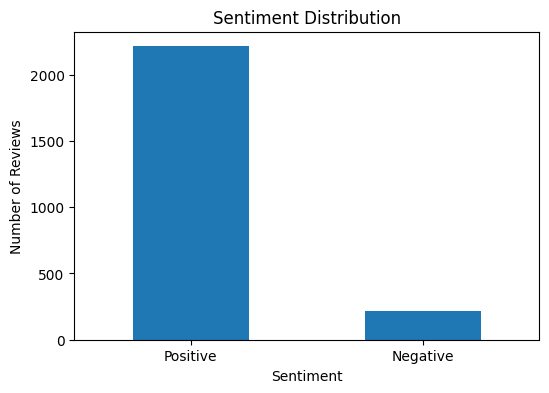

In [48]:
plt.figure(figsize=(6,4))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks([0,1],["Positive","Negative"], rotation=0)

plt.show()

**Saving the Figure**

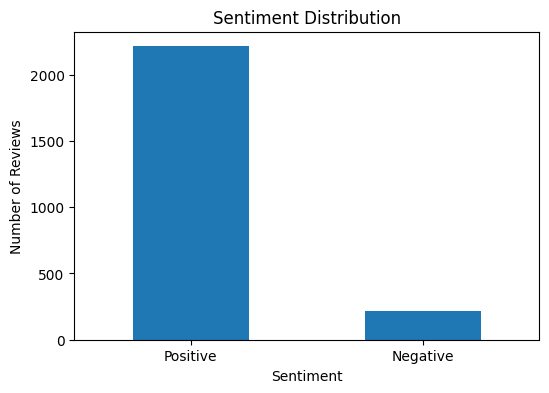

In [49]:
plt.figure(figsize=(6,4))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks([0,1],["Positive","Negative"], rotation=0)

plt.savefig("../outputs/sentiment_distribution.png")

plt.show()

### Observations

- The dataset contains both positive and negative reviews.
- Positive reviews are significantly more frequent than negative reviews.
- The dataset is imbalanced, which should be considered during model evaluation.